# Modelo Transformers

In [1]:
# ==========================
# 1. Importación de librerías
# ==========================
import os, gc
from pathlib import Path
import numpy as np
import pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, TrainerCallback
)
import evaluate


c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================
# 2. Carga y limpieza desde único dataset
# ==========================
DATA_PATH = Path(r"C:\Users\Sistemas\Desktop\beto solo grid\nuevo_df.csv")
df = pd.read_csv(DATA_PATH)

# --- Limpieza mínima ---
df['texto_completo'] = df['clean_text'].fillna('').str.strip()
df['Nivel_f']        = df['Nivel_f'].fillna('').str.strip()

# --- Codificación de etiquetas ---
label_encoder  = LabelEncoder()
df['label']    = label_encoder.fit_transform(df['Nivel_f'])

print("Clases codificadas:", dict(enumerate(label_encoder.classes_)))


Clases codificadas: {0: 'Alto', 1: 'Bajo', 2: 'Medio alto', 3: 'Medio bajo'}


In [3]:
# ==========================
# 3. División de train / val / test (desde un solo dataset)
# ==========================
# Paso 1: train/test (80% - 20%)
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

# Paso 2: train/val (de train original: 90% - 10%)
train_df, val_df = train_test_split(
    train_df, test_size=0.1, random_state=42, stratify=train_df['label']
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")



Train: 1382 | Val: 154 | Test: 384


In [4]:
# ==========================
# 4. Pesos de clase (para la pérdida)
# ==========================
class_weights = torch.tensor(
    compute_class_weight(class_weight='balanced',
                         classes=np.unique(train_df['label']),
                         y=train_df['label']),
    dtype=torch.float
)


In [5]:
# ==========================
# BÚSQUEDA MANUAL DE HIPERPARÁMETROS
# ==========================
from itertools import product
from copy import deepcopy
from tqdm import tqdm

# ---------- Grilla de hiperparámetros ----------
# param_grid = {
#     "learning_rate": [1e-4, 3e-5, 4e-5],
#     "per_device_train_batch_size": [8, 16],
#     "num_train_epochs": [10, 15],
#     "weight_decay": [0.0, 0.2],
#     "lr_scheduler_type": ["cosine"]
# }

param_grid = {
    "learning_rate": [1e-5, 3e-5],  # Aprendizaje más lento estabiliza
    "per_device_train_batch_size": [8, 16],  # Más pequeño = más ruido = más generalización
    "num_train_epochs": [10],  # Control de sobreajuste en número de épocas
    "weight_decay": [0.01, 0.1, 0.2],  # Penaliza magnitud de pesos
    "lr_scheduler_type": ["cosine"],  # Cosine decae mejor con menos overfitting
    "warmup_ratio": [0.05, 0.1],  # Inicio suave para evitar aprender demasiado rápido
    "gradient_accumulation_steps": [2, 3],  # Simula batch más grande, mejora estabilidad
    "fp16": [True],  # Usa media precisión para estabilidad y velocidad si tu GPU lo permite
}

# Generar combinaciones de hiperparámetros
keys = list(param_grid.keys())
combinations = list(product(*param_grid.values()))
print(f"Total combinaciones a evaluar: {len(combinations)}")


Total combinaciones a evaluar: 48


In [6]:
# ---------- Tokenizador y modelo base ----------
#model_name = "dccuchile/bert-base-spanish-wwm-cased"
model_name = "PlanTL-GOB-ES/roberta-base-bne"

tokenizer  = AutoTokenizer.from_pretrained(model_name)
model_base = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=len(label_encoder.classes_)
)

# ---------- Conversión a datasets ----------
def to_hfds(df):
    return Dataset.from_pandas(df[['texto_completo', 'label']])

train_ds = to_hfds(train_df)
val_ds   = to_hfds(val_df)
test_ds  = to_hfds(test_df)

# Tokenización
def tok(batch):
    return tokenizer(
        batch["texto_completo"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

def tok2(batch):
    return tokenizer(batch["texto_completo"],
                    truncation=True,
                    padding="max_length",
                    max_length=512,
                    
# Estos para SLIDING WINDO -----------------------               
                    stride=128,
                    return_overflowing_tokens=True,
                    return_special_tokens_mask=True)

train_ds = train_ds.map(tok, batched=True).remove_columns("texto_completo")
val_ds   = val_ds.map(tok, batched=True).remove_columns("texto_completo")
#test_ds  = test_ds.map(tok, batched=True).remove_columns("texto_completo")



# Para SLIDING WIENDOW ---------------------------
from collections import defaultdict

# Crear dataset de test manualmente (sin modificar el original)
test_ds_windowed = Dataset.from_pandas(test_df[['texto_completo', 'label']])

# Tokenizar con sliding window
tokenized_test = tokenizer(
    test_ds_windowed["texto_completo"],
    truncation=True,
    padding="max_length",
    max_length=512,
    stride=128,
    return_overflowing_tokens=True,
    return_special_tokens_mask=True,
    return_tensors=None
)

# Guardar mapeo de fragmentos a textos originales
test_ds_windowed = test_ds_windowed.map(tok2, batched=True)
sample_mapping = test_ds_windowed["overflow_to_sample_mapping"]
test_ds_windowed = test_ds_windowed.remove_columns("texto_completo")
test_ds_windowed.set_format("torch")




# Formato PyTorch
for ds in (train_ds, val_ds, test_ds):
    ds.set_format("torch")

# ---------- Métricas ----------
accuracy  = evaluate.load("accuracy")
f1        = evaluate.load("f1")
precision = evaluate.load("precision")
recall    = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy"        : accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro"        : f1.compute(predictions=preds, references=labels, average="macro")["f1"],
        "precision_macro" : precision.compute(predictions=preds, references=labels, average="macro")["precision"],
        "recall_macro"    : recall.compute(predictions=preds, references=labels, average="macro")["recall"],
    }

class MetricPrinter(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None: return
        print(f"Época {int(state.epoch):>2} | "
              f"Acc={metrics.get('eval_accuracy', 0):.4f}  "
              f"F1={metrics.get('eval_f1_macro', 0):.4f}  "
              f"Prec={metrics.get('eval_precision_macro', 0):.4f}  "
              f"Rec={metrics.get('eval_recall_macro', 0):.4f}")


# ---------- Trainer personalizado ----------
"""
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=class_weights.to(model.device))(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss
"""

class FocalLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        ce_loss = nn.functional.cross_entropy(logits, labels, weight=class_weights.to(model.device), reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** 2 * ce_loss).mean()
        return (focal_loss, outputs) if return_outputs else focal_loss


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at PlanTL-GOB-ES/roberta-base-bne and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 384/384 [00:00<00:00, 3991.78 examples/s]


In [7]:
# ---------- Búsqueda ----------
out_root = r"C:\Users\Sistemas\Desktop\beto solo grid\out beto grid 1"
os.makedirs(out_root, exist_ok=True)
resultados_grid = []

for i, valores in enumerate(tqdm(combinations, desc="🔁 Ejecutando combinaciones")):
    params = dict(zip(keys, valores))
    print(f"\nCombinación {i+1}/{len(combinations)}: {params}")

    output_dir_i = os.path.join(out_root, f"beto_grid_run_{i}")
    os.makedirs(output_dir_i, exist_ok=True)

    training_args = TrainingArguments(
        output_dir=output_dir_i,
        evaluation_strategy="epoch",
        save_strategy="no",
        logging_strategy="no",
        learning_rate=params["learning_rate"],
        per_device_train_batch_size=params["per_device_train_batch_size"],
        per_device_eval_batch_size=8,
        num_train_epochs=params["num_train_epochs"],
        weight_decay=params["weight_decay"],
        lr_scheduler_type=params["lr_scheduler_type"],
        load_best_model_at_end=False,
        seed=42,
        warmup_ratio=params["warmup_ratio"],
        gradient_accumulation_steps=params["gradient_accumulation_steps"],
        fp16=params["fp16"],
        disable_tqdm=True
    )

    trainer = FocalLossTrainer(
        model=deepcopy(model_base),
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )

    trainer.train()
    metrics = trainer.evaluate()
    resultados_grid.append({**params, **metrics})

    # Liberar memoria
    del trainer
    torch.cuda.empty_cache()
    gc.collect()



🔁 Ejecutando combinaciones:   0%|          | 0/48 [00:00<?, ?it/s]c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\transformers\training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\Sistemas\AppData\Local\Temp\ipykernel_26392\2194212552.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalLossTrainer.__init__`. Use `processing_class` instead.
  trainer = FocalLossTrainer(



Combinación 1/48: {'learning_rate': 1e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 10, 'weight_decay': 0.01, 'lr_scheduler_type': 'cosine', 'warmup_ratio': 0.05, 'gradient_accumulation_steps': 2, 'fp16': True}
{'eval_loss': 0.5277063250541687, 'eval_accuracy': 0.34415584415584416, 'eval_f1_macro': 0.32311926320409884, 'eval_precision_macro': 0.38922332035539586, 'eval_recall_macro': 0.490979020979021, 'eval_runtime': 0.7629, 'eval_samples_per_second': 201.865, 'eval_steps_per_second': 26.216, 'epoch': 0.9942196531791907}
{'eval_loss': 0.5103223919868469, 'eval_accuracy': 0.42207792207792205, 'eval_f1_macro': 0.4160423301513186, 'eval_precision_macro': 0.49364468625587704, 'eval_recall_macro': 0.5237587412587412, 'eval_runtime': 0.816, 'eval_samples_per_second': 188.727, 'eval_steps_per_second': 24.51, 'epoch': 2.0}
{'eval_loss': 0.6864924430847168, 'eval_accuracy': 0.4025974025974026, 'eval_f1_macro': 0.40859262080550024, 'eval_precision_macro': 0.4323568645914109, 'eval

🔁 Ejecutando combinaciones:   2%|▏         | 1/48 [04:02<3:09:58, 242.51s/it]c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\transformers\training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\Sistemas\AppData\Local\Temp\ipykernel_26392\2194212552.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalLossTrainer.__init__`. Use `processing_class` instead.
  trainer = FocalLossTrainer(



Combinación 2/48: {'learning_rate': 1e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 10, 'weight_decay': 0.01, 'lr_scheduler_type': 'cosine', 'warmup_ratio': 0.05, 'gradient_accumulation_steps': 3, 'fp16': True}


c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

🔁 Ejecutando combinaciones:  98%|█████████▊| 47/48 [2:57:41<03:35, 215.74s/it]c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\transformers\training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\Sistemas\AppData\Local\Temp\ipykernel_26392\2194212552.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalLossTrainer.__init__`. Use `processing_class` instead.
  trainer = FocalLossTrainer(



Combinación 48/48: {'learning_rate': 3e-05, 'per_device_train_batch_size': 16, 'num_train_epochs': 10, 'weight_decay': 0.2, 'lr_scheduler_type': 'cosine', 'warmup_ratio': 0.1, 'gradient_accumulation_steps': 3, 'fp16': True}


c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'eval_loss': 0.5881365537643433, 'eval_accuracy': 0.2922077922077922, 'eval_f1_macro': 0.23680064271061643, 'eval_precision_macro': 0.4037828947368421, 'eval_recall_macro': 0.47480769230769226, 'eval_runtime': 0.7864, 'eval_samples_per_second': 195.827, 'eval_steps_per_second': 25.432, 'epoch': 1.0}
{'eval_loss': 0.6257038116455078, 'eval_accuracy': 0.42857142857142855, 'eval_f1_macro': 0.4149688158771422, 'eval_precision_macro': 0.5717187741835629, 'eval_recall_macro': 0.5211713286713286, 'eval_runtime': 0.7891, 'eval_samples_per_second': 195.15, 'eval_steps_per_second': 25.344, 'epoch': 2.0}
{'eval_loss': 0.5792964696884155, 'eval_accuracy': 0.38961038961038963, 'eval_f1_macro': 0.3995239304233903, 'eval_precision_macro': 0.3913408251231527, 'eval_recall_macro': 0.4897027972027972, 'eval_runtime': 0.7924, 'eval_samples_per_second': 194.347, 'eval_steps_per_second': 25.24, 'epoch': 3.0}
{'eval_loss': 0.6260943412780762, 'eval_accuracy': 0.4675324675324675, 'eval_f1_macro': 0.48149032

🔁 Ejecutando combinaciones: 100%|██████████| 48/48 [3:01:14<00:00, 226.56s/it]


In [8]:
# ==========================
# GUARDAR Y MOSTRAR RESULTADOS
# ==========================
df_resultados = pd.DataFrame(resultados_grid)
df_ordenado = df_resultados.sort_values("eval_f1_macro", ascending=False)

print("\nTop combinaciones por F1 macro:")
print(df_ordenado[[
    "eval_f1_macro", "eval_accuracy", "learning_rate",
    "per_device_train_batch_size", "num_train_epochs",
    "weight_decay", "lr_scheduler_type"
]].head(5).round(4))

# Guardar en CSV
csv_path = os.path.join(out_root, "resultados_beto_grid_search.csv")
df_ordenado.to_csv(csv_path, index=False)
print(f"Resultados guardados en: {csv_path}")



Top combinaciones por F1 macro:
    eval_f1_macro  eval_accuracy  learning_rate  per_device_train_batch_size  \
25         0.5788         0.5714            0.0                            8   
43         0.5715         0.5584            0.0                           16   
26         0.5536         0.5519            0.0                            8   
33         0.5516         0.5325            0.0                            8   
44         0.5506         0.5390            0.0                           16   

    num_train_epochs  weight_decay lr_scheduler_type  
25                10          0.01            cosine  
43                10          0.10            cosine  
26                10          0.01            cosine  
33                10          0.20            cosine  
44                10          0.20            cosine  
Resultados guardados en: C:\Users\Sistemas\Desktop\beto solo grid\out beto grid 1\resultados_beto_grid_search.csv


In [9]:
# ==========================
# ENTRENAMIENTO FINAL CON MEJORES HIPERPARÁMETROS
# ==========================
mejores_params = df_ordenado.iloc[0][keys].to_dict()
print("\nMejor combinación encontrada:")
print(mejores_params)

# Ruta final de salida
output_dir_final = os.path.join(out_root, "beto_modelo_final")
os.makedirs(output_dir_final, exist_ok=True)

# Argumentos finales de entrenamiento
# training_args_final = TrainingArguments(
#     output_dir=output_dir_final,
#     evaluation_strategy="epoch",
#     save_strategy="epoch",
#     logging_strategy="steps",
#     logging_steps=10,
#     learning_rate=mejores_params["learning_rate"],
#     per_device_train_batch_size=mejores_params["per_device_train_batch_size"],
#     per_device_eval_batch_size=8,
#     num_train_epochs=mejores_params["num_train_epochs"],
#     weight_decay=mejores_params["weight_decay"],
#     lr_scheduler_type=mejores_params["lr_scheduler_type"],
#     load_best_model_at_end=True,
#     metric_for_best_model="f1_macro",
#     greater_is_better=True,
#     save_total_limit=2,
#     seed=42
# )

training_args_final = TrainingArguments(
    output_dir=output_dir_final,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    learning_rate=mejores_params["learning_rate"],
    per_device_train_batch_size=mejores_params["per_device_train_batch_size"],
    per_device_eval_batch_size=8,
    num_train_epochs=mejores_params["num_train_epochs"],
    weight_decay=mejores_params["weight_decay"],
    lr_scheduler_type=mejores_params["lr_scheduler_type"],
    warmup_ratio=mejores_params["warmup_ratio"],  # NUEVO
    gradient_accumulation_steps=mejores_params["gradient_accumulation_steps"],  # NUEVO
    fp16=mejores_params["fp16"],  # NUEVO
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    seed=42
)

# Entrenador final
trainer_final = FocalLossTrainer(
    model=deepcopy(model_base),
    args=training_args_final,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2),
               MetricPrinter()]
)

# Entrenamiento completo
trainer_final.train()
print("Evaluación final en validación:", trainer_final.evaluate())


c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\transformers\training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(



Mejor combinación encontrada:
{'learning_rate': 3e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 10, 'weight_decay': 0.01, 'lr_scheduler_type': 'cosine', 'warmup_ratio': 0.05, 'gradient_accumulation_steps': 3, 'fp16': True}


C:\Users\Sistemas\AppData\Local\Temp\ipykernel_26392\4171177400.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalLossTrainer.__init__`. Use `processing_class` instead.
  trainer_final = FocalLossTrainer(
  2%|▏         | 10/570 [00:03<03:38,  2.57it/s]

{'loss': 2.4195, 'grad_norm': 1.386009931564331, 'learning_rate': 1.0344827586206898e-05, 'epoch': 0.17}


  4%|▎         | 20/570 [00:07<03:35,  2.55it/s]

...

{'eval_loss': 0.9924787878990173, 'eval_accuracy': 0.5194805194805194, 'eval_f1_macro': 0.5361693810972444, 'eval_precision_macro': 0.5398185603103636, 'eval_recall_macro': 0.5477272727272727, 'eval_runtime': 0.8011, 'eval_samples_per_second': 192.24, 'eval_steps_per_second': 24.966, 'epoch': 6.0}
Época  6 | Acc=0.5195  F1=0.5362  Prec=0.5398  Rec=0.5477


 61%|██████    | 346/570 [02:29<01:36,  2.31it/s]


{'train_runtime': 149.6826, 'train_samples_per_second': 92.329, 'train_steps_per_second': 3.808, 'train_loss': 0.9569077069704244, 'epoch': 6.0}


100%|██████████| 20/20 [00:00<00:00, 26.11it/s]

Época  6 | Acc=0.5584  F1=0.5683  Prec=0.5719  Rec=0.5808
Evaluación final en validación: {'eval_loss': 0.6815536618232727, 'eval_accuracy': 0.5584415584415584, 'eval_f1_macro': 0.5682933401406853, 'eval_precision_macro': 0.5718632280498407, 'eval_recall_macro': 0.5807692307692307, 'eval_runtime': 0.812, 'eval_samples_per_second': 189.653, 'eval_steps_per_second': 24.63, 'epoch': 6.0}


100%|██████████| 48/48 [00:01<00:00, 25.82it/s]



Tabla de métricas (Test final):

Model Type        Class precision    recall        f1 support  accuracy  log_loss       auc
 BETO test         Alto  0.357143  0.446429  0.396825      56         -         -  0.784789
 BETO test         Bajo  0.606557  0.596774  0.601626      62         -         -  0.895412
 BETO test   Medio alto  0.503401  0.540146  0.521127     137         -         -  0.703153
 BETO test   Medio bajo  0.509434  0.418605  0.459574     129         -         -  0.706034
 BETO test    macro avg  0.494134  0.500488  0.494788     384         -         -  0.772347
 BETO test weighted avg  0.500754  0.494792  0.495319     384         -         -         -
 BETO test       global         -         -         -       -  0.494792  1.088272  0.792083

Métricas guardadas en: C:\Users\Sistemas\Desktop\beto solo grid\out beto grid 1\beto_modelo_final\metricas_test_final.csv


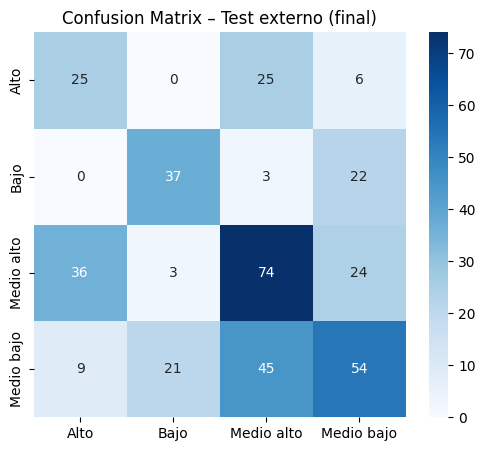

In [10]:
# ---------- PREDICCIÓN EN TEST ----------
# preds_test = trainer_final.predict(test_ds)
# y_logits = preds_test.predictions
# y_pred   = np.argmax(y_logits, axis=-1)
# y_true   = preds_test.label_ids

# Para SLIDING WINDOW------------------------
# Realizar predicción en todos los fragmentos
preds_test = trainer_final.predict(test_ds_windowed)
logits = preds_test.predictions
labels = preds_test.label_ids

# Agrupar logits por texto original y promediar
logits_por_texto = defaultdict(list)
labels_por_texto = {}

for i, idx in enumerate(sample_mapping):
    logits_por_texto[idx].append(logits[i])
    labels_por_texto[idx] = labels[i]

# Promediar logits y reconstruir predicción final
y_logits = []
y_true   = []
for idx in sorted(logits_por_texto):
    media_logits = np.mean(logits_por_texto[idx], axis=0)
    y_logits.append(media_logits)
    y_true.append(labels_por_texto[idx])

y_logits = np.array(y_logits)
y_pred   = np.argmax(y_logits, axis=-1)
y_true   = np.array(y_true)


# ---------- MÉTRICAS Y TABLA ----------
from sklearn.metrics import (
    roc_auc_score, log_loss,
    precision_recall_fscore_support, accuracy_score
)

probas = torch.softmax(torch.tensor(y_logits), dim=-1).numpy()

prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred,
    labels=np.arange(len(label_encoder.classes_)),
    zero_division=0
)
auc_per_class = roc_auc_score(
    y_true, probas, multi_class="ovr", average=None
)

rows = []
for idx, cls_name in enumerate(label_encoder.classes_):
    rows.append(dict(
        Model="BETO",
        Type="test",
        Class=cls_name,
        precision=prec[idx],
        recall=rec[idx],
        f1=f1[idx],
        support=support[idx],
        accuracy="-",
        log_loss="-",
        auc=auc_per_class[idx]
    ))

prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)
auc_macro = roc_auc_score(y_true, probas, multi_class="ovr", average="macro")
auc_micro = roc_auc_score(y_true, probas, multi_class="ovr", average="micro")
acc       = accuracy_score(y_true, y_pred)
lloss     = log_loss(y_true, probas)

rows += [
    dict(Model="BETO", Type="test", Class="macro avg",
         precision=prec_m, recall=rec_m, f1=f1_m,
         support=support.sum(), accuracy="-", log_loss="-", auc=auc_macro),
    dict(Model="BETO", Type="test", Class="weighted avg",
         precision=prec_w, recall=rec_w, f1=f1_w,
         support=support.sum(), accuracy="-", log_loss="-", auc="-"),
    dict(Model="BETO", Type="test", Class="global",
         precision="-", recall="-", f1="-", support="-",
         accuracy=acc, log_loss=lloss, auc=auc_micro)
]

metric_df = pd.DataFrame(rows)

# Mostrar tabla
pd.set_option("display.max_columns", None)
print("\nTabla de métricas (Test final):\n")
print(metric_df.round(3).to_string(index=False))

# Guardar CSV
metric_df.to_csv(os.path.join(output_dir_final, "metricas_test_final.csv"), index=False)
print(f"\nMétricas guardadas en: {output_dir_final}\\metricas_test_final.csv")

# ---------- MATRIZ DE CONFUSIÓN ----------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix – Test externo (final)")
plt.show()

# %%

# Mejor combinación encontrada:
# {'learning_rate': 3e-05, 'per_device_train_batch_size': 16, 'num_train_epochs': 15, 'weight_decay': 0.0, 'lr_scheduler_type': 'cosine'}
# c:\users\sistemas\desktop\beto solo grid\prueba_gpt_beto_grid_1.py:250: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
#   trainer_final = WeightedTrainer(
# <IPython.core.display.HTML object>
# Época  1 | Acc=0.3766  F1=0.3958  Prec=0.4375  Rec=0.4905
# Época  2 | Acc=0.4545  F1=0.4731  Prec=0.4931  Rec=0.5427
# Época  3 | Acc=0.4740  F1=0.4883  Prec=0.5207  Rec=0.5241
# Época  4 | Acc=0.5649  F1=0.5693  Prec=0.5667  Rec=0.5749
# Época  5 | Acc=0.5390  F1=0.5370  Prec=0.5475  Rec=0.5286
# Época  6 | Acc=0.5195  F1=0.5141  Prec=0.5173  Rec=0.5169
# <IPython.core.display.HTML object>
# Época  6 | Acc=0.5649  F1=0.5693  Prec=0.5667  Rec=0.5749
# Evaluación final en validación: {'eval_loss': 1.185158610343933, 'eval_accuracy': 0.564935064935065, 'eval_f1_macro': 0.5692557246616103, 'eval_precision_macro': 0.5666666666666667, 'eval_recall_macro': 0.5749300699300699, 'eval_runtime': 3.0829, 'eval_samples_per_second': 49.953, 'eval_steps_per_second': 6.487, 'epoch': 6.0}

# Tabla de métricas (Test final):

# Model Type        Class precision    recall        f1 support  accuracy  log_loss       auc
#  BETO test         Alto  0.446154  0.517857  0.479339      56         -         -  0.820176
#  BETO test         Bajo  0.636364  0.564516  0.598291      62         -         -  0.889752
#  BETO test   Medio alto   0.52518  0.532847  0.528986     137         -         -  0.714885
#  BETO test   Medio bajo     0.496   0.48062  0.488189     129         -         -  0.693479
#  BETO test    macro avg  0.525924   0.52396  0.523701     384         -         -  0.779573
#  BETO test weighted avg  0.521804  0.518229   0.51923     384         -         -         -
#  BETO test       global         -         -         -       -  0.518229  1.203617  0.799848

# ✅ Métricas guardadas en: C:\Users\Sistemas\Desktop\beto solo grid\out beto grid 1\beto_modelo_final\metricas_test_final.csv



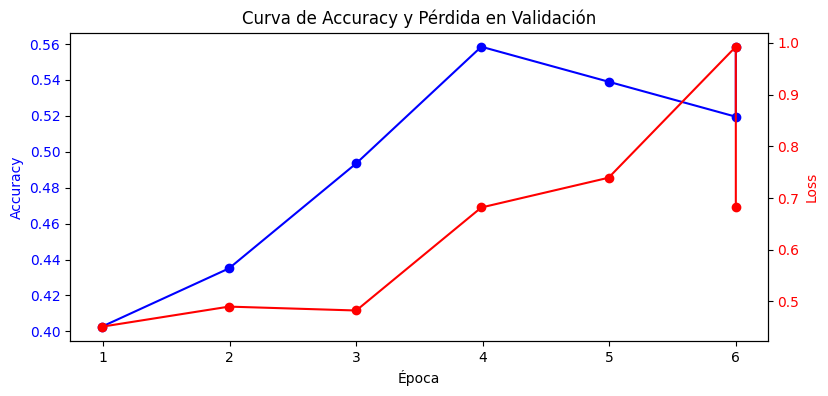

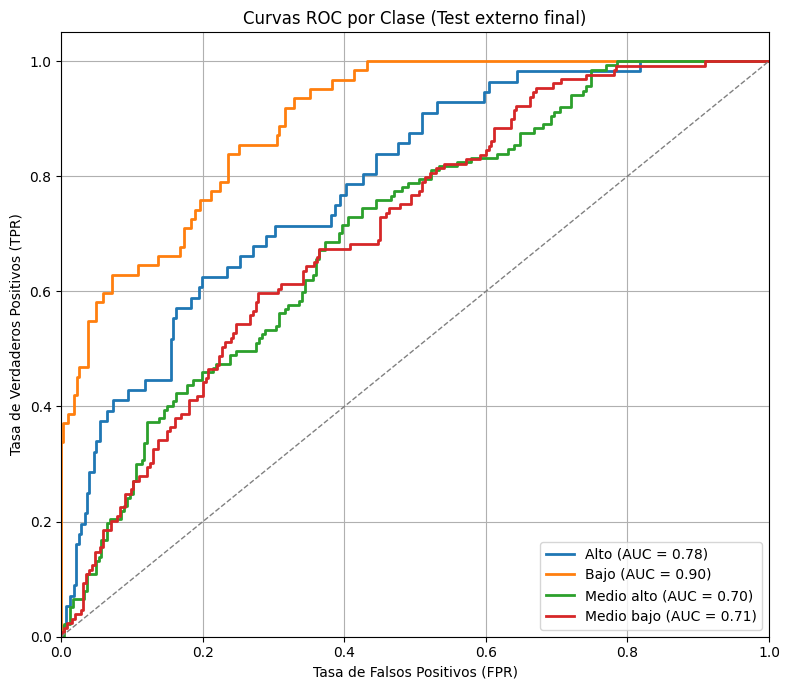

In [11]:
# ===========================
# Curva de Accuracy y Pérdida (Loss) por época
# ===========================
# Se extrae el historial del Trainer
if hasattr(trainer_final, 'state') and hasattr(trainer_final.state, 'log_history'):
    history = pd.DataFrame(trainer_final.state.log_history)
    # Filtramos solo los logs de evaluación para accuracy y loss
    epochs = history[history.eval_accuracy.notnull()].epoch
    accs   = history[history.eval_accuracy.notnull()].eval_accuracy
    losses = history[history.eval_loss.notnull()].eval_loss

    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax1.plot(epochs, accs, marker='o', label="Accuracy (validación)", color='b')
    ax1.set_xlabel("Época")
    ax1.set_ylabel("Accuracy", color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_title("Curva de Accuracy y Pérdida en Validación")

    ax2 = ax1.twinx()
    ax2.plot(epochs, losses, marker='o', label="Loss (validación)", color='r')
    ax2.set_ylabel("Loss", color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    plt.show()
else:
    print("Historial de entrenamiento no disponible en trainer_final.")

# ===========================
# 2. Curvas ROC por clase (Test externo)
# ===========================
from sklearn.metrics import roc_curve, auc

n_classes = len(label_encoder.classes_)
plt.figure(figsize=(8, 7))

for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve((y_true == i).astype(int), probas[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curvas ROC por Clase (Test externo final)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
